In [69]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json

import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [70]:
hessianShiftForStiffness = 1e-7


In [71]:
importlib.reload(pattern_generator_using_gmsh)

<module 'pattern_generator_using_gmsh' from '/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/out_of_plane_patches/../../pattern_generator_using_gmsh.py'>

In [155]:
angle = 90
r = 2.5
avg_len = 0.1


h = 5
dh = 1
# dw = 3.5
# dw = 2
dw = 3

m, marker = pattern_generator_using_gmsh.get_biaxial_pattern(h, dh, dw, 2, avg_len)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

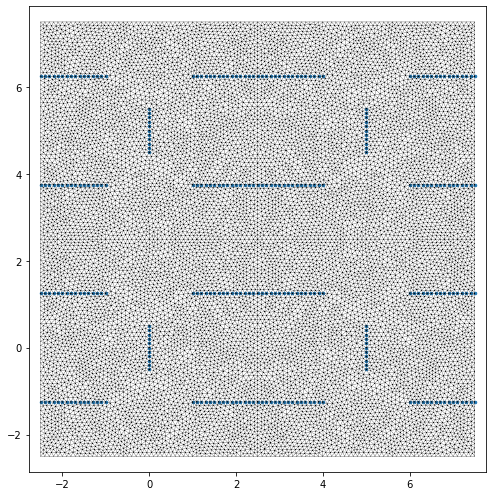

In [156]:
visualization.plot_2d_mesh(m, pointList = fusedVtx)

In [157]:
tag = "{}_{}_{}".format(h, dh, dw)
m.save("mesh_{}.obj".format(tag))
np.save("fusedVtx_{}.npy".format(tag), fusedVtx)

In [158]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(True)
viewer.show()


Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [159]:
import experiment_helper

In [160]:
import tri_mesh_viewer

In [167]:
viewer = tri_mesh_viewer.OffscreenTriMeshViewer(ipu, width = 1000, height = 1000)

In [168]:
viewer.setCameraParams(((6, 0, 4),
 (-1, -0, 0),
 (0.0, 0.0, 0.0)))

In [169]:
# viewer.getCameraParams()

In [170]:
viewer.recordStart("out_of_plane_deformation_bending.mp4", outWidth = 1000, outHeight = 1000, streaming = True)

In [171]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [172]:
allowBending = True
useTFT = True
disableFusedRegionTFT = False

In [173]:
def cb(i):
    # viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
    viewer.update()

In [174]:
# ipu.setVars(np.load('{}_vars.npy'.format(tag)))

In [175]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6
    
fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
# viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

True 0.4 1e-06 []
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.00411797	1
InflatableSheet setVars	0.001302	1
Newton iterations	30.4072	1
    InflatableSheet energy	0.000889063	3
    Newton iterate	30.4061	113
        Backtracking	0.371274	112
            InflatableSheet energy	0.146615	468
            InflatableSheet setVars	0.0843699	156
        Compute descent direction	21.2777	112
            Negative curvature dir	0.185329	5
                negativeCurvatureDirection	0.184439	5
                    Catamari Solve	0.160013	45
                        IPermute	0.00298452	45
                        OpenMPLowerTransposeTriangularSolve	0.0630708	45
                        OpenMPLowerTriangularSolve	0.0918505	45
                        Permute	0.00181222	45
            newton_step	21.092	112
                Catamari Symbolic Factorize	0.256029	1
                    CatamariConverter	0.0407131	1
                    Construct plan	0.00397992	1
             

In [176]:
viewer.recordStop()

In [222]:
import periodic_simulation_setup

In [223]:
periodic_simulation_setup.reparametrize_gamma_bar(ipu)


In [224]:
np.save("{}_{}_{}_vars.npy".format(h, dh, dw), ipu.getVars())

In [225]:
import parametrization_helper

In [226]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'inflated_shape')

In [227]:
np.set_printoptions(suppress=True, precision=4)

In [228]:
ipu.getVars()[:3], ipu.getVars()[-2:]

(array([0.9267, 0.6864, 0.    ]), array([-0.4794, -0.    ]))

In [175]:
kappa = ipu.getVars()[-2]
alpha = ipu.getVars()[-1]

In [176]:
z = ipu.getVars()[3:-2].reshape((-1, 3))[:, 2]

In [178]:
ipu_vars = ipu.getVars()
ipu_vars[-2] = -kappa

In [179]:
ipu.setVars(ipu_vars)

### Mid-surface

In [467]:
kappa = 0

In [468]:
angle = 90
r = 2.5
avg_len = 0.1


h = 5
dh = 1
dw = 3


mid_surface = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

In [469]:
mid_surface_viewer = TriMeshViewer(mid_surface, width=768, height=640)
mid_surface_viewer.showWireframe(True)
mid_surface_viewer.show()


Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [470]:
curr_vars = mid_surface.getVars()

In [474]:
curr_vars[:3] = ipu.getVars()[:3]
curr_vars[-2:] = ipu.getVars()[-2:]
curr_vars[-2] = 0

In [475]:
mid_surface.setVars(curr_vars)

In [476]:
mid_surface_viewer.update()

### Save data

In [477]:
import os

In [478]:
import parametrization_helper

In [479]:
# tag = 'out_of_plane'
tag = 'in_plane'

In [480]:
output_folder = 'output/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [481]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, output_folder, tag, 'inflated_shape')

m.save("{}/mesh_{}.obj".format('.', tag))
np.save("{}/fusedVtx_{}.npy".format('.', tag), fusedVtx)

In [482]:
parametrization_helper.export_top_bottom_mesh(mid_surface.sheet, output_folder, tag, 'mid_surface')

m.save("{}/mesh_{}.obj".format('.', tag))
np.save("{}/fusedVtx_{}.npy".format('.', tag), fusedVtx)

In [483]:
curr_x_vars = mid_surface.getVars()[3:-2].reshape((-1, 3))

In [484]:
curr_x_vars[:, 2] = np.max(z)

In [485]:
curr_vars[3:-2] = curr_x_vars.flatten()

In [486]:
mid_surface.setVars(curr_vars)

In [487]:
parametrization_helper.export_top_bottom_mesh(mid_surface.sheet, output_folder, tag, 'top_surface')

m.save("{}/mesh_{}.obj".format('.', tag))
np.save("{}/fusedVtx_{}.npy".format('.', tag), fusedVtx)

In [488]:
curr_x_vars = mid_surface.getVars()[3:-2].reshape((-1, 3))

In [489]:
curr_x_vars[:, 2] = np.min(z)

In [490]:
curr_vars[3:-2] = curr_x_vars.flatten()
mid_surface.setVars(curr_vars)

In [491]:
parametrization_helper.export_top_bottom_mesh(mid_surface.sheet, output_folder, tag, 'bottom_surface')

m.save("{}/mesh_{}.obj".format('.', tag))
np.save("{}/fusedVtx_{}.npy".format('.', tag), fusedVtx)